<a href="https://colab.research.google.com/github/Eda-Yildirim/sisterslab_veribilimi/blob/main/sklearnwload_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

# Iris veri setini kullandım
iris = load_iris()

# Veriyi DataFrame'e çevirdim
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# İlk 5 satırı göstermek için kullandım
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Lojistik Regresyon
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# 2. Karar Ağacı
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

# 3. Destek Vektör Makineleri (SVM)
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

# Doğruluk skorlarını yazdır
print(f"Logistic Regression Accuracy: {acc_lr:.2f}")
print(f"Decision Tree Accuracy:      {acc_tree:.2f}")
print(f"SVM Accuracy:                {acc_svm:.2f}")


Logistic Regression Accuracy: 1.00
Decision Tree Accuracy:      1.00
SVM Accuracy:                1.00


Classification Report (SVM):

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



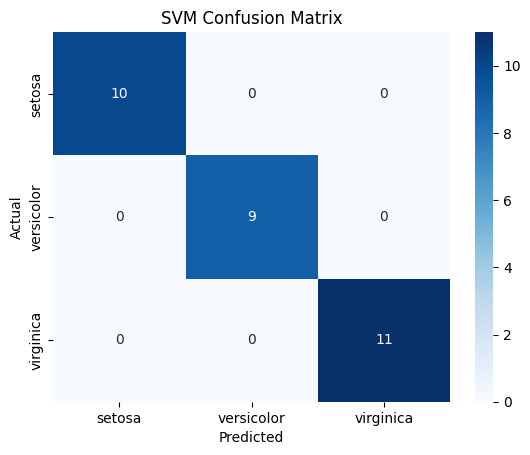

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


print("Classification Report (SVM):\n")
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))


conf_mat = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_mat, annot=True, cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()
